In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated, List
from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

In [ ]:

load_dotenv(override=True)
import os

def get_groq_llm():
    return ChatOpenAI(
        model="gpt-4o-mini",
        api_key=os.getenv("OPENAI_API_KEY"),
        temperature=0.4,
        max_tokens=2000
    )

llm = get_groq_llm()

In [5]:
class JokeState(TypedDict):
    topic: str
    joke:str
    explanation: str

In [6]:
def generate_joke(state:JokeState):
    prompt = f"generate a joke on the topic {state['topic']}"
    response = llm.invoke(prompt).content

    return {'joke': response}

In [7]:
def generate_explaination(state: JokeState):
    prompt = f"write an explaination for the joke - {state['joke']}"
    response = llm.invoke(prompt).content

    return {'explaination':response}

In [8]:
graph = StateGraph(JokeState)

graph.add_node("generate_joke", generate_joke)
graph.add_node("generate_explaination", generate_explaination)

graph.add_edge(START, 'generate_joke')
graph.add_edge("generate_joke","generate_explaination")
graph.add_edge("generate_explaination", END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

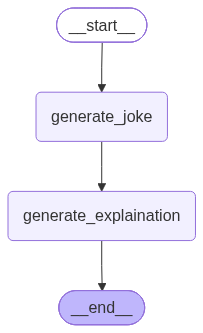

In [9]:
workflow

In [25]:
config1={"configurable":{"thread_id": "1"}}
workflow.invoke({"topic":"pizza"}, config=config1)

{'topic': 'pizza', 'joke': ''}

### Get current state of workflow

In [ ]:
workflow.get_state(config1)     

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to therapy?\n\nBecause it had too many toppings to deal with. 🍕'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1ac2ab-9a88-6956-8006-c7af48ce742a'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, created_at='2026-09-09T08:44:52.862983+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1ac2ab-79b0-6d61-8005-639e8a2cce63'}}, tasks=(), interrupts=())

### Get all state listing of workflow. 

### StateSnapshot 
```text
Langgraph will take/store the value of each state variables when any state change. this process is callled State Snapshot```

In [42]:
list(workflow.get_state_history(config1))   

[StateSnapshot(values={'topic': 'burgur'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1ac3ea-00ea-6691-8001-5ef3212a2520'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-09-09T11:07:19.846019+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1ac37f-e045-662a-8000-f7887dcb0a33'}}, tasks=(PregelTask(id='90e35299-b1f9-52f4-a3e6-43728c499ac7', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a loan? It needed the dough.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1ac3e0-8600-6992-8003-e6b404a713e9'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-09-09T11:03:05.365731+00:00', parent_config={'configurable': {'thr

In [27]:
config2={"configurable":{"thread_id": "2"}}
workflow.invoke({"topic":"momoj"}, config=config2)

{'topic': 'momoj',
 'joke': 'Why do momos make terrible secret agents? Because they always reveal their fillings.'}

In [28]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'momoj', 'joke': 'Why do momos make terrible secret agents? Because they always reveal their fillings.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1ac3b7-074f-6939-8002-00a4f2de40d1'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-09-09T10:44:31.495786+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1ac3b6-6fcc-6827-8001-66b85128df25'}}, tasks=(), interrupts=())

In [29]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'momoj', 'joke': 'Why do momos make terrible secret agents? Because they always reveal their fillings.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1ac3b7-074f-6939-8002-00a4f2de40d1'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-09-09T10:44:31.495786+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1ac3b6-6fcc-6827-8001-66b85128df25'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'momoj', 'joke': 'Why do momos make terrible secret agents? Because they always reveal their fillings.'}, next=('generate_explaination',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1ac3b6-6fcc-6827-8001-66b85128df25'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-09-09T10:44:15.608604+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'chec

### Time Travel
### We can go back to any previous mode to do the execution again for debugging & changing the input as well

In [ ]:
workflow.get_state({"configurable":{"thread_id":"1", "checkpoint_id":"1f1ac37f-e045-662a-8000-f7887dcb0a33"}})
#i have put the checkpoint_id of the config1 state (2nd step) and it show that statesnapshot

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f1ac37f-e045-662a-8000-f7887dcb0a33'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-09-09T10:19:51.007155+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1ac37f-e041-6cf2-bfff-e6ec13b7c4f8'}}, tasks=(PregelTask(id='d6c73b41-2224-e1dc-1b7a-5ac4b0f8e5db', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': ''}),), interrupts=())

In [40]:
workflow.invoke(None,
    {"configurable":{"thread_id":"1", "checkpoint_id":"1f1ac37f-e045-662a-8000-f7887dcb0a33"}}
)

{'topic': 'pizza',
 'joke': 'Why did the pizza apply for a loan? It needed the dough.'}

In [ ]:
workflow.update_state(
    {"configurable":{"thread_id":"1", "checkpoint_id":"1f1ac37f-e045-662a-8000-f7887dcb0a33", 'checkpoint_ns': ''}},
    {"topic":"burgur"}
)  # upadte that state topic "pizza" to "burgur" and it genearte new checkpoint_id after updating state.

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1ac3ed-65f6-6d45-8001-022d87320fa4'}}

In [47]:
list(workflow.get_state_history(config1)) 

[StateSnapshot(values={'topic': 'burgur', 'joke': "Here's a burger joke for you:\n\nWhy did the hamburger go to therapy? It couldn't stop bottling up its beef."}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1ac3f0-1577-66d9-8003-51efcc52d340'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-09-09T11:10:03.062222+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1ac3ef-a35a-6705-8002-cc5bac222f83'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'burgur', 'joke': "Here's a burger joke for you:\n\nWhy did the hamburger go to therapy? It couldn't stop bottling up its beef."}, next=('generate_explaination',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1ac3ef-a35a-6705-8002-cc5bac222f83'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-09-09T11:09:51.096583+00:00', parent_config={'configurab

In [46]:
workflow.invoke(None,
    {"configurable":{"thread_id":"1", "checkpoint_id":"1f1ac3ed-65f6-6d45-8001-022d87320fa4"}}
)

{'topic': 'burgur',
 'joke': "Here's a burger joke for you:\n\nWhy did the hamburger go to therapy? It couldn't stop bottling up its beef."}